# Assignment 2 – Sentiment Classification with Neural Language Models (Stage 1)

Sentiment classification of movie reviews into binary categories (0 = negative, 1 = positive) using the Pang & Lee polarity dataset, where we train on an intentionally small (240 reviews) and imbalanced (180/60) training dataset.

**Final model:** An ensemble of 5 linear classifiers (implemented in PyTorch) using frozen pretrained GloVe-300 word embeddings (mean-pooled) concatenated with 6 negation-aware sentiment-lexicon features.

Shared code for featurization, training, and saving checkpoints lives in `sentiment_lib.py` to be reused in Stage 2 for inference-only evaluation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay

import sentiment_lib as sl

SEED = 42
np.random.seed(SEED)

## 1. Data

`train.csv` (240 reviews, imbalance 3:1) serves for training; `public_test.csv` (400 reviews, balanced) serves for evaluation purposes only, and will never enter training, feature fit, and model selection processes.

In [2]:
train = pd.read_csv("train.csv")
test = pd.read_csv("public_test.csv")

print("train:", train.shape, dict(train["label"].value_counts()))
print("test :", test.shape, dict(test["label"].value_counts()))
train.head(3)[["id", "label", "label_name"]]

train: (240, 5) {1: np.int64(180), 0: np.int64(60)}
test : (400, 5) {1: np.int64(200), 0: np.int64(200)}


,id,label,label_name
0,pos_cv230_7428,1,positive
1,pos_cv853_29233,1,positive
2,pos_cv771_28665,1,positive


## 2. Model structure

**What is the model?** An ensemble of 5 identical linear classifiers `nn.Linear(306, 2)` implemented in PyTorch (each one is multinomial logistic regression), which are applied to a fixed 306 dimensional representation of each review:

1. **pretrained word embeddings (300 dimensions).** Every token in the text is looked up in GloVe `glove-wiki-gigaword-300` (vocabulary size 400k words, trained on 6B tokens), and the review is represented by the mean of its word embeddings. Embeddings are frozen because with 240 training documents it is impossible to fine-tune 120M embedding parameters.
2. **sentiment-lexicon features (6 dimensions).** Count of positive and negative words from the Hu & Liu opinion lexicon per 100 tokens in the text, and their difference, as well as negation-aware versions of all three of these features (a lexicon word preceded by a negator such as "not good", "never boring" changes polarity).

Features are standardized (means and stds calculated only in each member's training split), and predictions from the 5 members are done by averaging their softmax outputs.

**Why so simple?** We compared a number of alternatives (results in §5): TF-IDF n-gram models trained from scratch, fastText-style EmbeddingBag network with trainable embeddings, and a MLP head on the same set of features. With so few examples, every model with higher capacity than linear head overfitted and performed worse on holdout data. The pretrained embeddings + linear head pair is the standard "frozen features, small head" trick for tiny datasets, and performed best in cross-validation.

## 3. Handling the small and imbalanced training set

* **Small (n=240) →** frozen pretrained features instead of learned ones; a linear head (~600 trainable parameters) instead of a deep network; strong AdamW weight decay (0.03); early stopping; and a 5-seed ensemble to reduce the variance due to the very small train/validation split.
* **Imbalanced (180/60) →** class-weighted cross-entropy with inverse-frequency weights, where each negative example counts three times as much as a positive one. Model selection is based on balanced accuracy evaluated on a stratified validation split, while the splits themselves are stratified to preserve the 3:1 ratio. We will verify below (confusion matrix) that the model does not degenerate into the majority class.
* **Unseen evaluation tokens →** the classifier does not see any raw token identities. GloVe is built for 400k words, thus words missing in the 240 training reviews (which account for the vast majority of all English) still get mapped to meaningful vectors. Opinion lexicon (~6.8k words) too generalizes to unseen reviews. Tokens not present in either of the resources are just ignored via mean pooling.

In [3]:
# Load pretrained resources (cached after the first download)
kv = sl.load_glove()          # GloVe 300-d, ~376 MB on first run
POS, NEG = sl.load_lexicon()  # Hu & Liu opinion lexicon via NLTK

X = sl.featurize(train["text"].tolist(), kv, POS, NEG)
X_test = sl.featurize(test["text"].tolist(), kv, POS, NEG)
y = train["label"].values
y_test = test["label"].values
print("feature matrices:", X.shape, X_test.shape)

feature matrices: (240, 306) (400, 306)


## 4. Training techniques

For each model ensemble member (seed 0 to 4):

* **Optimization routine:** AdamW, learning rate 5e-3, weight decay 0.03 (the primary regularizer for the linear head; selected via 5-fold CV on the training set).
* **Loss function:** cross-entropy with inverse-frequency class weights (≈ [2.0, 0.67] for [neg, pos]).
* **Batch size:** full batch (192 training rows easily fit in memory; full-batch gradients are stable at this size).
* **Early stopping:** each model keeps its own 20% stratified validation split (48 reviews) from the training set; training stops if there is no improvement in the validation balanced accuracy within 60 epochs (max 400 epochs), and the best weights are restored.
* **Ensembling:** the 5 models have different train/val splits and initializations; averaging their probability outputs smooths out the variance induced by splits (which is considerable at n=240).

Training is CPU-only and takes a few seconds.

In [4]:
members = sl.train_ensemble(X, y)
sl.save_checkpoint(members, "model_checkpoint")
print("checkpoint saved to model_checkpoint/")

seed 0: best val balanced accuracy = 0.722
seed 1: best val balanced accuracy = 0.792


seed 2: best val balanced accuracy = 0.792
seed 3: best val balanced accuracy = 0.764


seed 4: best val balanced accuracy = 0.750
checkpoint saved to model_checkpoint/


## 5. What else we tried (model comparison)

5-fold cross-validation of the balanced accuracy on the training set (public test accuracy shown for reference only; it was never used for model selection):

| Approach | CV bal. acc. | Public test acc. |
|---|---|---|
| TF-IDF word 1-2 grams + logistic regression | 0.55-0.59 | 0.56-0.61 |
| TF-IDF char 2-5 grams + linear SVM / LR | 0.63 | 0.62-0.63 |
| fastText-style trainable EmbeddingBag (word + hashed char n-grams) | 0.66 | — |
| GloVe-300 mean + MLP (128 hidden, dropout 0.5) | ~0.71 | 0.72-0.74 |
| **GloVe-300 mean + lexicon + linear head (submitted)** | **0.73** | **0.76** |

Training from scratch on 240 documents yielded worse results than using the frozen pretrained features, while MLP head was worse than the plain linear head – in line with the overfitting risks mentioned in the assignment.

## 6. Evaluation on the public test set

The model is loaded from the saved checkpoint (Stage-2 inference is verified) and we report total accuracy and a confusion matrix.

public test accuracy          : 0.7575
public test balanced accuracy : 0.7575


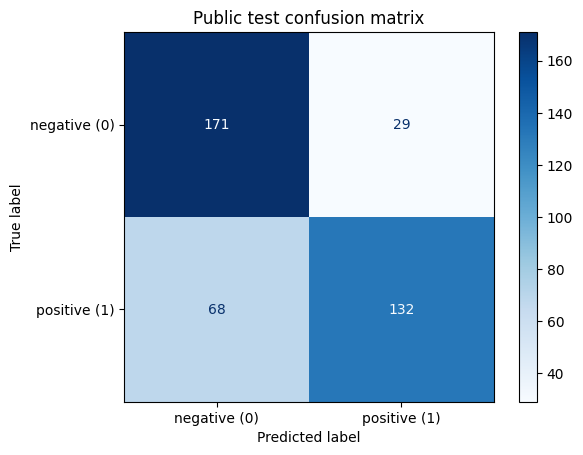

[[171  29]
 [ 68 132]]


In [5]:
members_loaded, cfg = sl.load_checkpoint("model_checkpoint")
pred = sl.predict(members_loaded, X_test)

acc = accuracy_score(y_test, pred)
bal = balanced_accuracy_score(y_test, pred)
print(f"public test accuracy          : {acc:.4f}")
print(f"public test balanced accuracy : {bal:.4f}")

cm = confusion_matrix(y_test, pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["negative (0)", "positive (1)"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Public test confusion matrix")
plt.show()
print(cm)

In [6]:
out = pd.DataFrame({"id": test["id"], "predicted_label": pred})
out.to_csv("public_test_predictions.csv", index=False)
out.head()

,id,predicted_label
0,pos_cv696_29740,1
1,pos_cv669_22995,1
2,neg_cv963_7208,0
3,pos_cv182_7281,0
4,pos_cv162_10424,1


## 7. Reproducibility notes

* All randomness is seeded (`torch`, `numpy`, `random`, split seeds = member seeds 0-4).
* `model_checkpoint/` contains everything needed to reload the trained model: `config.json`, per-member `model_seed{i}.pt` state dicts and `scaler_seed{i}.npz` standardization statistics. Inference re-computes GloVe/lexicon features via automatic cached downloads (gensim / NLTK).

## References and Use of AI

* Pang & Lee (2004) movie review polarity corpus (course-provided / NLTK release)
* Pennington, Socher & Manning (2014) GloVe: Global Vectors for Word Representation – pre-trained GloVe vectors provided through `gensim.downloader`
* Hu & Liu (2004) Mining and Summarizing Customer Reviews – opinion lexicon provided through NLTK

**Use of AI:** Claude assisted with the coding during the implementation stage. The bot’s work was mainly to provide boilerplate for the featurization and training process and help script the sweeps of comparisons in section 5. I performed all the experiment design, selection of models, and the result interpretation. All design decisions were validated through cross-validation in the training set without any modification or labeling of the training or test sets.